Veri yükleniyor ve ön işleme yapılıyor...
VAE Modeli kuruluyor...
Model sadece normal verilerle eğitiliyor...
Epoch 1/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 11.4825
Epoch 2/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.7735
Epoch 3/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.5162
Epoch 4/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.4016
Epoch 5/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.2802
Epoch 6/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.2233
Epoch 7/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1989
Epoch 8/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1861
Epoch 9/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1522
Epoch 10/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1408
Epoch 11/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1253
Epoch 12/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1158
Epoch 13/15
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1008
Epoch 14/15
26

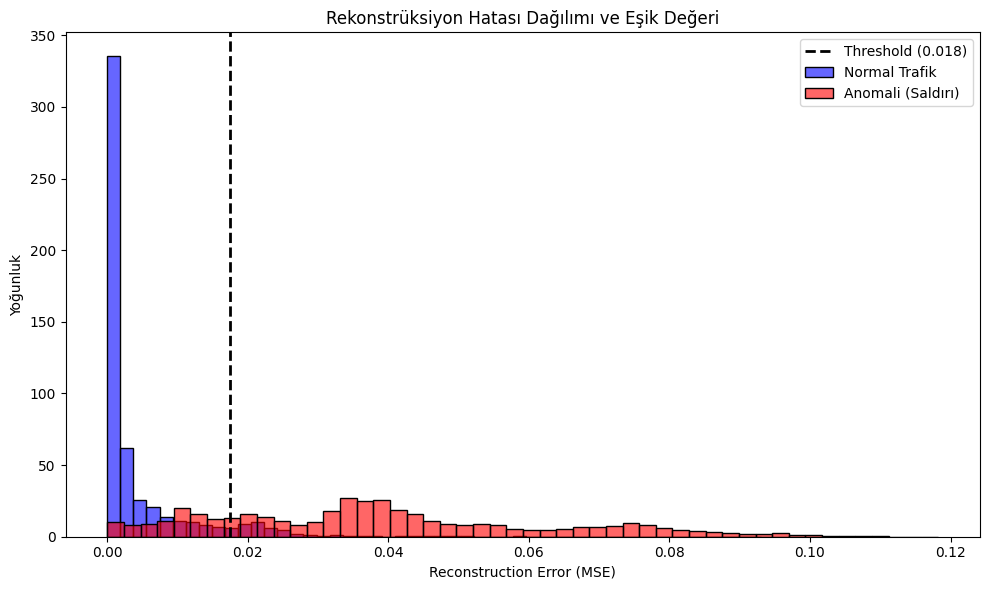

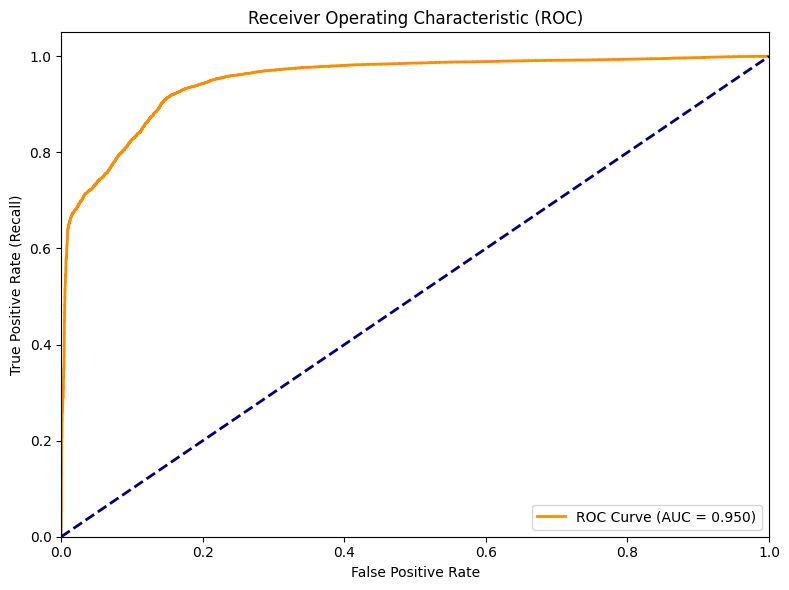

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve

# 1. VERİ YÜKLEME VE ÖN İŞLEME
print("Veri yükleniyor ve ön işleme yapılıyor...")

# NSL-KDD Sütun İsimleri
columns = (['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot',
            'num_failed_logins','logged_in','num_compromised','root_shell','su_attempt','num_root','num_file_creations',
            'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count',
            'serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
            'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
            'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','label', 'difficulty_level'])

# Eğitim ve Test verilerini okuma 
train_df = pd.read_csv("../data/KDDTrain+.txt", header=None, names=columns)
test_df = pd.read_csv("../data/KDDTest+.txt", header=None, names=columns)


train_df.drop('difficulty_level', axis=1, inplace=True)
test_df.drop('difficulty_level', axis=1, inplace=True)

# Etiketleri Binary (0: Normal, 1: Anomali) hale getirme
train_df['label'] = train_df['label'].apply(lambda x: 0 if x == 'normal' else 1)
test_df['label'] = test_df['label'].apply(lambda x: 0 if x == 'normal' else 1)

X_train = train_df.drop('label', axis=1)
y_train = train_df['label']
X_test = test_df.drop('label', axis=1)
y_test = test_df['label']

# Kategorik ve Sayısal Sütunları Ayırma
categorical_cols = ['protocol_type', 'service', 'flag']
numerical_cols = X_train.columns.difference(categorical_cols)

# Pipeline- Sayısalları 0-1 arasına çek, Kategorikleri One-Hot yap
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Pipeline'ı eğitme ve verileri dönüştürme
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# SADECE NORMAL VERİLERİ ALIYORUZ (VAE modelimiz sadece normalin ne olduğunu öğrenecek)
X_train_normal = X_train_processed[y_train == 0]

# 2. VAE (VARIATIONAL AUTOENCODER) MODELİ KURULUMU
print("VAE Modeli kuruluyor...")
input_dim = X_train_normal.shape[1]
latent_dim = 4  # Latent Space boyutu

# --- ENCODER ---
inputs = layers.Input(shape=(input_dim,))
h = layers.Dense(64, activation='relu')(inputs)
h = layers.Dense(32, activation='relu')(h)

z_mean = layers.Dense(latent_dim, name='z_mean')(h)
z_log_var = layers.Dense(latent_dim, name='z_log_var')(h)

def sampling(args):
    z_mean, z_log_var = args
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]
    epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling, output_shape=(latent_dim,), name='z')([z_mean, z_log_var])
encoder = Model(inputs, [z_mean, z_log_var, z], name='encoder')

# --- DECODER ---
latent_inputs = layers.Input(shape=(latent_dim,), name='z_sampling')
h_decoded = layers.Dense(32, activation='relu')(latent_inputs)
h_decoded = layers.Dense(64, activation='relu')(h_decoded)
outputs = layers.Dense(input_dim, activation='sigmoid')(h_decoded)
decoder = Model(latent_inputs, outputs, name='decoder')

# --- ÖZEL VAE SINIFI---

class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            # Modelin içinden veriyi geçir
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            
            # Kayıpları hesapla
            reconstruction_loss = tf.reduce_mean(tf.square(data - reconstruction)) * input_dim
            kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            total_loss = reconstruction_loss + kl_loss
            
        # Backpropagation
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        
        return {"loss": self.total_loss_tracker.result()}
        
    def call(self, inputs):
        # Sadece predict yapmak istediğimizde çalışacak kısım
        _, _, z = self.encoder(inputs)
        return self.decoder(z)

# Modeli oluştur ve derle
vae = VAE(encoder, decoder)
vae.compile(optimizer='adam')

# ==========================================
# 3. MODELİ EĞİTME
# ==========================================
print("Model sadece normal verilerle eğitiliyor...")
history = vae.fit(
    X_train_normal, 
    epochs=15, 
    batch_size=256,
    verbose=1
)
# ==========================================
# 4. TEST, REKONSTRÜKSİYON HATASI VE THRESHOLD
# ==========================================
print("Test verisi üzerinde değerlendirme yapılıyor...")
# Test seti üzerinde tahmin
X_test_pred = vae.predict(X_test_processed)

# Test seti için her bir örneğin Ortalama Kare Hatasını (MSE) hesapla
mse = np.mean(np.power(X_test_processed - X_test_pred, 2), axis=1)

# Threshold Belirleme
# Normal eğitim verilerinin hatalarını hesapla ve %95'lik eşik yap
mse_train = np.mean(np.power(X_train_normal - vae.predict(X_train_normal), 2), axis=1)
threshold = np.percentile(mse_train, 95)
print(f"\n---> Belirlenen Anomali Eşik Değeri (Threshold): {threshold:.5f} <---")

# Tahminleri Sınıflandırma (Eşikten büyükse 1: Saldırı, küçükse 0: Normal)
y_pred = (mse > threshold).astype(int)

# ==========================================
# 5. İSTENEN METRİKLERİN HESAPLANMASI
# ==========================================
print("\n--- DEĞERLENDİRME METRİKLERİ ---")
roc_auc = roc_auc_score(y_test, mse) 
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
fpr = fp / (fp + tn)

print(f"ROC-AUC Skoru : %{roc_auc*100:.2f}")
print(f"Precision     : %{precision*100:.2f}")
print(f"Recall        : %{recall*100:.2f}")
print(f"F1-score      : %{f1*100:.2f}")
print(f"False Positive Rate (FPR): %{fpr*100:.2f}")

# 6. GÖRSELLEŞTİRME

# GRAFİK 1: Rekonstrüksiyon Hatası Dağılımı ve Threshold
plt.figure(figsize=(10, 6))
sns.histplot(mse[y_test == 0], bins=50, color='blue', alpha=0.6, label='Normal Trafik', stat='density')
sns.histplot(mse[y_test == 1], bins=50, color='red', alpha=0.6, label='Anomali (Saldırı)', stat='density')
plt.axvline(threshold, color='black', linestyle='dashed', linewidth=2, label=f'Threshold ({threshold:.3f})')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Yoğunluk')
plt.title('Rekonstrüksiyon Hatası Dağılımı ve Eşik Değeri')
plt.legend()
plt.tight_layout()
plt.savefig('../presentation/reconstruction_error_distribution.png')
plt.show()

# GRAFİK 2: ROC Curve
fpr_roc, tpr_roc, thresholds_roc = roc_curve(y_test, mse)
plt.figure(figsize=(8, 6))
plt.plot(fpr_roc, tpr_roc, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('../presentation/roc_curve.png')
plt.show()